# Behind-the-meter PV: grid-direct vs. self-consumption vs. self-consumption+storage

For grid-level demand/generation modeling, what matters isn't just how
much solar capacity exists, but how much of it feeds straight into the
grid vs. is consumed behind the meter first. Each solar unit is
classified using MaStR's `feed_in_type` field plus a location-based join
against storage units (see `edh/capacity_panel.py::classify_pv_category`
in `energy-data-hub` for the full methodology and why simpler approaches
-- a same-location flag MaStR itself provides, and storage's own
"co-registered solar unit" field -- don't work well here).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

from insights.paths import hub_file

events = pd.read_parquet(hub_file("capacity", "capacity_events.parquet"))
pv_panel = pd.read_parquet(hub_file("capacity", "capacity_by_region_year_pv_category.parquet"))
regions = gpd.read_file(hub_file("regions", "nuts_regions.geojson"))

solar = events[events["technology"] == "solar"]

PV_CATEGORY_ORDER = ["full_feed_in", "self_consumption_no_storage", "self_consumption_with_storage"]
PV_CATEGORY_LABELS = {
    "full_feed_in": "Full grid feed-in",
    "self_consumption_no_storage": "Self-consumption (no storage)",
    "self_consumption_with_storage": "Self-consumption + storage",
}
PV_CATEGORY_COLORS = {
    "full_feed_in": "#E8A33D",
    "self_consumption_no_storage": "#C97A2B",
    "self_consumption_with_storage": "#8B4A1E",
}
CHART_START_YEAR = 1990

## Overview

In [2]:
known = solar[solar["pv_category"] != "unknown"]
print("Capacity (MW) and unit count by category:")
print(
    known.groupby("pv_category", observed=True)
    .agg(capacity_mw=("capacity_mw", "sum"), units=("unit_id", "count"))
    .reindex(PV_CATEGORY_ORDER)
    .round(0)
)
print(f"\n'unknown' category: {(solar['pv_category'] == 'unknown').sum():,} units")

Capacity (MW) and unit count by category:


                               capacity_mw    units
pv_category                                        
full_feed_in                       62486.0  1133174
self_consumption_no_storage        31842.0  3070325
self_consumption_with_storage      17039.0  2013378

'unknown' category: 17,479 units


## Over time

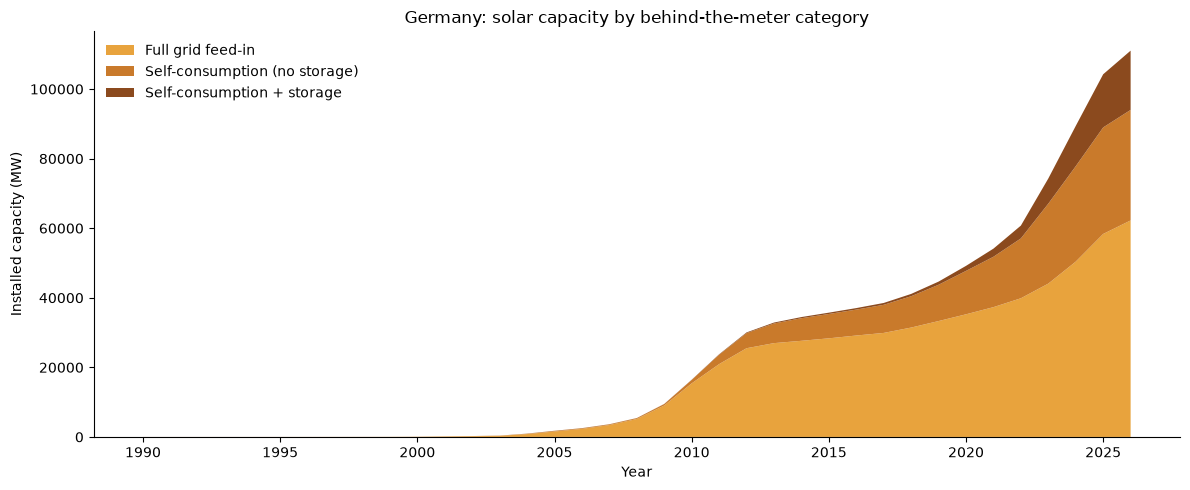

In [3]:
pv_known = pv_panel[pv_panel["pv_category"] != "unknown"]
pv_national = pv_known.groupby(["year", "pv_category"])["capacity_mw"].sum().unstack("pv_category")
pv_national = pv_national.reindex(columns=PV_CATEGORY_ORDER, fill_value=0.0)
pv_national = pv_national[pv_national.index >= CHART_START_YEAR]

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(
    pv_national.index,
    [pv_national[cat] for cat in PV_CATEGORY_ORDER],
    labels=[PV_CATEGORY_LABELS[cat] for cat in PV_CATEGORY_ORDER],
    colors=[PV_CATEGORY_COLORS[cat] for cat in PV_CATEGORY_ORDER],
)
ax.set_xlabel("Year")
ax.set_ylabel("Installed capacity (MW)")
ax.set_title("Germany: solar capacity by behind-the-meter category")
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## Is the mix similar across Germany?

Share of each category within each state's total solar capacity, latest
snapshot. If the bars look similar across states, the national split
above is a reasonable stand-in per region for grid modeling; if a state
stands out, it needs its own mix rather than the national average.

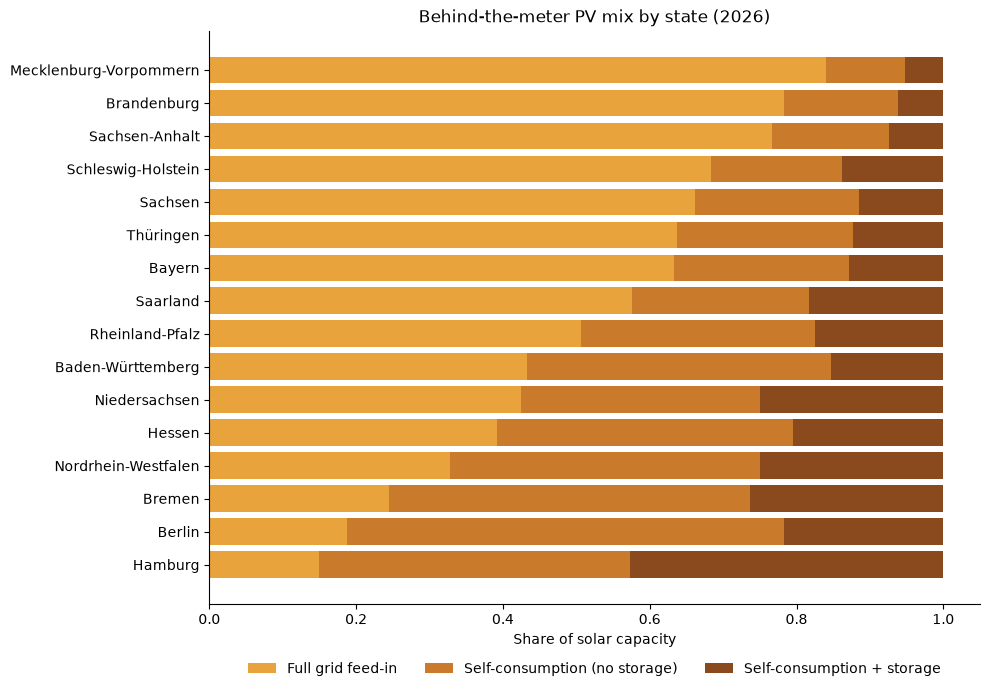

Spread across states (max - min share, by category):
pv_category
full_feed_in                     0.691
self_consumption_no_storage      0.488
self_consumption_with_storage    0.375
dtype: float64


In [4]:
latest_year = pv_panel["year"].max()
nuts1_names = regions.loc[regions["LEVL_CODE"] == 1].set_index("NUTS_ID")["NUTS_NAME"]

pv_latest_onshore = pv_known[
    (pv_known["year"] == latest_year) & (~pv_known["region_code"].str.startswith("DEZZ"))
].copy()
pv_latest_onshore["state"] = pv_latest_onshore["region_code"].str[:3].map(nuts1_names)

by_state = (
    pv_latest_onshore.groupby(["state", "pv_category"])["capacity_mw"]
    .sum()
    .unstack("pv_category")
    .reindex(columns=PV_CATEGORY_ORDER, fill_value=0.0)
)
by_state_share = by_state.div(by_state.sum(axis=1), axis=0).sort_values("full_feed_in")

fig, ax = plt.subplots(figsize=(10, 7))
left = pd.Series(0.0, index=by_state_share.index)
for cat in PV_CATEGORY_ORDER:
    ax.barh(by_state_share.index, by_state_share[cat], left=left, color=PV_CATEGORY_COLORS[cat], label=PV_CATEGORY_LABELS[cat])
    left = left + by_state_share[cat]
ax.set_xlabel("Share of solar capacity")
ax.set_title(f"Behind-the-meter PV mix by state ({latest_year})")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

print("Spread across states (max - min share, by category):")
print((by_state_share.max() - by_state_share.min()).round(3))

## Plant size distribution by category

Expectation: household PV is small and mostly self-consumption, so
full-feed-in should skew toward much larger plants than either
self-consumption category.

Capacity per unit (kW) by category:


                                   count  mean    std  min  25%  50%   75%  \
pv_category                                                                  
full_feed_in                   1133174.0  55.1  640.2  0.0  5.0  9.6  22.8   
self_consumption_no_storage    3070325.0  10.4  145.3  0.0  0.8  5.0   9.2   
self_consumption_with_storage  2013378.0   8.5   16.1  0.0  5.0  8.0  10.0   

                                90%       max  
pv_category                                    
full_feed_in                   42.0  111250.0  
self_consumption_no_storage    15.0  144000.0  
self_consumption_with_storage  14.4    8170.0  


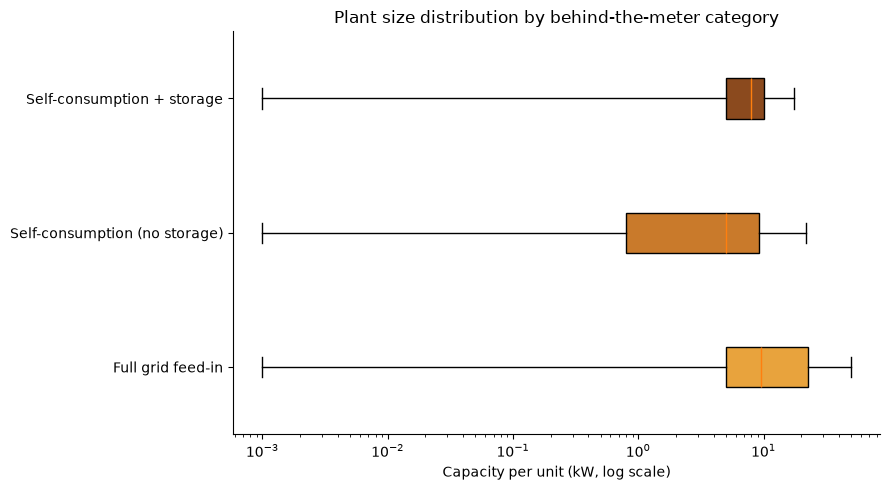

In [5]:
solar_known = solar[solar["pv_category"] != "unknown"].copy()
solar_known["capacity_kw"] = solar_known["capacity_mw"] * 1000.0

print("Capacity per unit (kW) by category:")
print(
    solar_known.groupby("pv_category", observed=True)["capacity_kw"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9])
    .reindex(PV_CATEGORY_ORDER)
    .round(1)
)

fig, ax = plt.subplots(figsize=(9, 5))
box_data = [solar_known.loc[solar_known["pv_category"] == cat, "capacity_kw"] for cat in PV_CATEGORY_ORDER]
bp = ax.boxplot(
    box_data,
    orientation="horizontal",
    showfliers=False,
    patch_artist=True,
    tick_labels=[PV_CATEGORY_LABELS[cat] for cat in PV_CATEGORY_ORDER],
)
for patch, cat in zip(bp["boxes"], PV_CATEGORY_ORDER):
    patch.set_facecolor(PV_CATEGORY_COLORS[cat])
ax.set_xscale("log")
ax.set_xlabel("Capacity per unit (kW, log scale)")
ax.set_title("Plant size distribution by behind-the-meter category")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## Cross-check against usage sector and installation type

Two independent MaStR fields not used in the classification itself --
`usage_sector` (household/commercial/industrial/agricultural) and
`installation_type` (rooftop/balcony/ground-mounted) -- should still line
up with it: full-feed-in should skew toward ground-mounted/commercial-
industrial, self-consumption toward household rooftop. This is a sanity
check on the classification, not a new category.

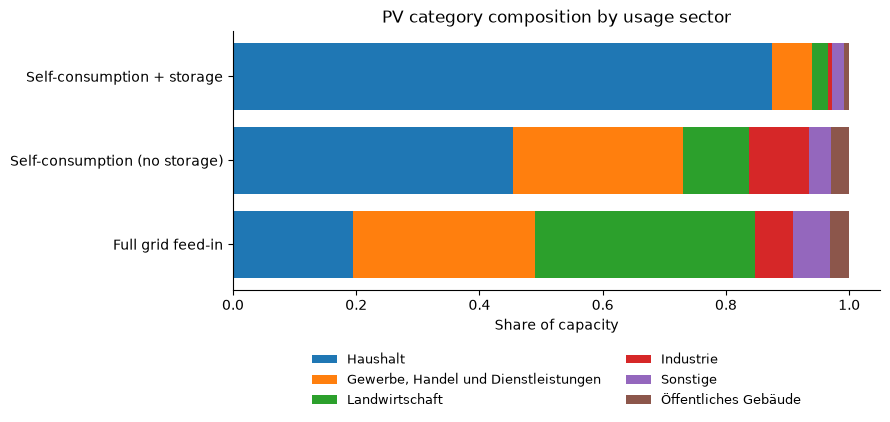

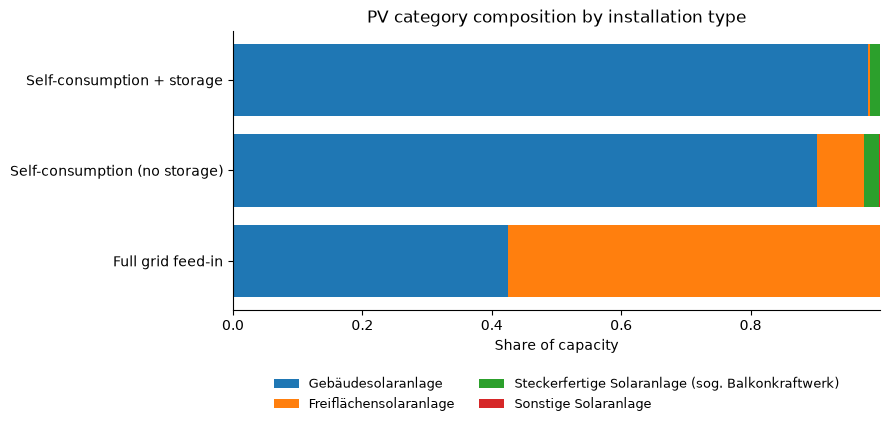

In [6]:
SUB_CATEGORY_COLORS = plt.get_cmap("tab10").colors


def pv_category_composition_chart(group_col, title):
    share = (
        solar_known.groupby(["pv_category", group_col], observed=True)["capacity_mw"]
        .sum()
        .unstack(group_col)
        .reindex(PV_CATEGORY_ORDER)
    )
    share = share.div(share.sum(axis=1), axis=0)
    share = share[share.sum().sort_values(ascending=False).index]  # largest sub-category first

    fig, ax = plt.subplots(figsize=(9, 4.5))
    bar_labels = [PV_CATEGORY_LABELS[cat] for cat in share.index]
    left = pd.Series(0.0, index=share.index)
    for i, col in enumerate(share.columns):
        ax.barh(bar_labels, share[col], left=left, color=SUB_CATEGORY_COLORS[i % len(SUB_CATEGORY_COLORS)], label=col)
        left = left + share[col]
    ax.set_xlabel("Share of capacity")
    ax.set_title(title)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.show()


pv_category_composition_chart("usage_sector", "PV category composition by usage sector")
pv_category_composition_chart("installation_type", "PV category composition by installation type")